# The crystal ball puzzle — how much light leaves as *scattered* light?

**Problem.** A crystal ball of radius $R$ and refractive index $n$ contains a tiny sphere of
fluorescent dye pressed against its inner surface. UV light from behind makes the dye radiate
visible light isotropically. The ball is anti-reflection coated (no partial reflections) but
microscopic impurities inside scatter light *weakly*. The picture below is what appears on a
screen in front of the ball; the white bar equals the ball diameter $d$. Absorption is
negligible. Which fraction of the emitted energy leaves the ball as scattered light?

![the figure](figure.png)

*(the dim parts of the figure are strongly brightness-enhanced)*

**Answer, up front:**

$$f_{\text{scattered}}=\cos\theta_c=\sqrt{1-\frac{1}{n^{2}}}\simeq 0.70 \qquad (n\simeq1.40)$$

The rest of the notebook is the reasoning: first the exact geometry (three lines of
trigonometry, no integrals), then the measurement of $n$ from the figure, then a brute-force
Monte Carlo photon tracer that reproduces the number without using any of the analytics.

---

## Part 1 — Why the answer is a single cosine

### 1.1 A ray that starts on the surface keeps its incidence angle forever

Put the dye at a point $S$ on the inner surface. A ray leaving $S$ into the glass is a **chord**
of the sphere, and a chord meets the sphere at the same angle at both ends (the triangle
$O\,S\,P$ is isosceles, $|OS| = |OP| = R$). So if the ray leaves $S$ at angle $\theta$ to the
inward normal, it lands on the far surface at incidence angle $\theta$ as well — and if it is
totally reflected there, it does so again, and again:

$$\theta_1=\theta_2=\theta_3=\dots=\theta$$

Equivalently: the impact parameter $p = R\sin\theta$ of a ray with respect to the centre is
conserved by reflection off a sphere. This is the whole trick of the problem.

### 1.2 Therefore every ray is decided at birth

With $\sin\theta_c = 1/n$:

* $\theta<\theta_c$ → the ray refracts out the **first** time it touches the surface. It crosses
  the ball once, so with weak scattering it leaves essentially unscattered.
* $\theta>\theta_c$ → total internal reflection, at the same angle, **forever**. Such a ray can
  never refract out. It is trapped no matter how many bounces we wait.

There is no slow leakage, no partial reflection (AR coating), and no absorption. The only exit
route left for a trapped ray is to hit an impurity: a scattering event randomises its direction
and hence its impact parameter, and sooner or later it gets $\theta<\theta_c$ and escapes.

**So "trapped" and "leaves as scattered light" are the same set of photons**, and the weakness of
the scattering does not matter at all: it only sets *how long* the trapped light rattles around,
not *how much* of it eventually comes out that way. (Weak scattering does matter in one respect:
it makes the probability that a *directly escaping* ray is scattered on its single pass through
the ball negligible.)

### 1.3 Counting solid angle

The dye sits on the surface, so the inward normal at $S$ is a natural axis. Emission into the
inward hemisphere at angle $\theta$ to the inward normal has incidence angle $\theta$ at the far
surface; emission into the outward hemisphere at angle $\psi$ to the outward normal hits the
surface immediately, at incidence angle $\psi$. Both hemispheres use the same criterion, so the
escaping directions form **two cones of half-angle $\theta_c$** around the normal, one in each
hemisphere:

$$f_{\text{direct}}=\frac{2\cdot 2\pi(1-\cos\theta_c)}{4\pi}=1-\cos\theta_c,
\qquad
f_{\text{scattered}}=\cos\theta_c=\sqrt{1-\frac{1}{n^{2}}}$$

One unknown is left: $n$. That is what the figure is for.

---

## Part 2 — Getting $n$ out of the figure

The picture has exactly two sharp circles, and the bar gives the scale $R=d/2$:

* a **small, flat-topped bright disc** with a thin brighter rim — the light that gets out of the
  ball directly (all of it comes from the critical cone, which is why it is bounded and sharp),
* a **large, very dim disc** — the trapped light slowly leaking out through the impurities, i.e.
  the whole body of the ball glowing. Because we look *through* the glass, the glowing interior
  is magnified: a feature at radius $\rho$ inside is seen at $n\rho$, so the glow ends at $nR$.

So the two measurable radii are

$$\frac{r_{\text{halo}}}{R}=n,\qquad\qquad \frac{r_{\text{disc}}}{R}=1-\cos\theta_c ,$$

and they are **two independent handles on the same single unknown** — a built-in consistency
check. Let us measure them from the pixels instead of with a ruler.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("figure.png").convert("L"), dtype=float)
height, width = img.shape
print("image size:", width, "x", height, "  brightest pixel:", img.max())

# --- the white scale bar: the first nearly-white horizontal rule near the top ---
for row in range(height // 4):
    white = np.nonzero(img[row] > 200)[0]
    if white.size > 50:
        d_pixels = float(white.max() - white.min())
        print(f"scale bar found on row {row}: d = {d_pixels:.0f} px")
        break

R = d_pixels / 2.0

image size: 1024 x 723   brightest pixel: 229.0
scale bar found on row 51: d = 454 px


In [2]:
# --- centre of the pattern, from the bright core (skip the top strip with the bar) ---
core = img > 150
core[: height // 8] = False
ys, xs = np.nonzero(core)
cx, cy = xs.mean(), ys.mean()
print(f"centre of the pattern: ({cx:.1f}, {cy:.1f})")

# --- azimuthally averaged radial profile ---
yy, xx = np.mgrid[0:height, 0:width]
radius = np.round(np.hypot(xx - cx, yy - cy)).astype(int)
counts = np.bincount(radius.ravel())
profile = np.bincount(radius.ravel(), img.ravel()) / counts


def falling_edge(lo, hi):
    """sub-pixel radius of the brightness drop between lo and hi (half-way level)"""
    half = 0.5 * (profile[lo] + profile[hi])
    for k in range(lo, hi):
        if profile[k + 1] < half <= profile[k]:
            return k + (profile[k] - half) / (profile[k] - profile[k + 1])
    raise ValueError("no edge in that window")


r_disc = falling_edge(60, 75)     # edge of the bright disc
r_halo = falling_edge(310, 325)   # edge of the dim halo

print(f"bright disc radius : {r_disc:6.1f} px = {r_disc / R:.3f} R")
print(f"halo radius        : {r_halo:6.1f} px = {r_halo / R:.3f} R")

centre of the pattern: (365.0, 377.4)
bright disc radius :   67.0 px = 0.295 R
halo radius        :  316.5 px = 1.394 R


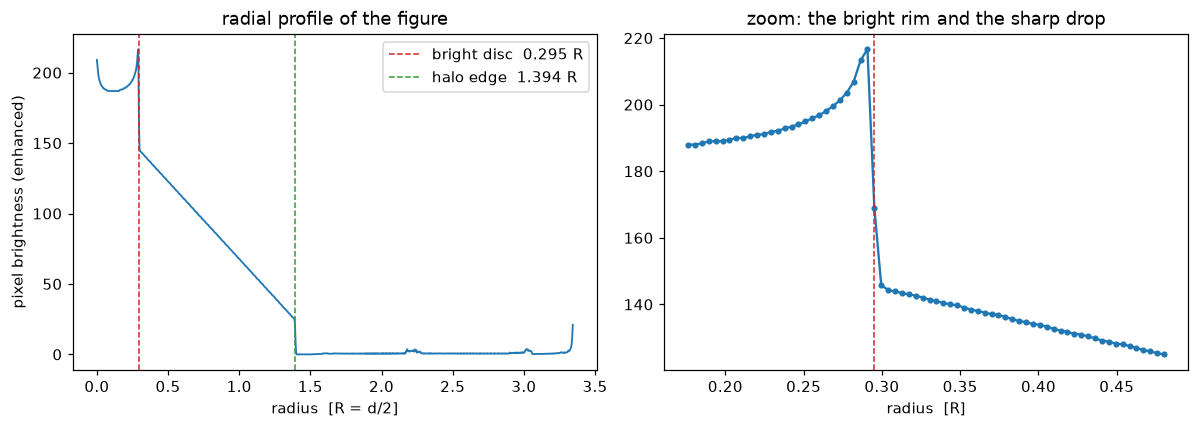

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(np.arange(len(profile)) / R, profile, lw=1.2)
ax[0].axvline(r_disc / R, color="tab:red", ls="--", lw=1,
              label=f"bright disc  {r_disc / R:.3f} R")
ax[0].axvline(r_halo / R, color="tab:green", ls="--", lw=1,
              label=f"halo edge  {r_halo / R:.3f} R")
ax[0].set_xlabel("radius  [R = d/2]")
ax[0].set_ylabel("pixel brightness (enhanced)")
ax[0].set_title("radial profile of the figure")
ax[0].legend()

ax[1].plot(np.arange(40, 110) / R, profile[40:110], marker=".")
ax[1].axvline(r_disc / R, color="tab:red", ls="--", lw=1)
ax[1].set_xlabel("radius  [R]")
ax[1].set_title("zoom: the bright rim and the sharp drop")

fig.tight_layout()
plt.show()

The profile is exactly what the model predicts: a flat plateau ending in a thin bright rim
(the caustic-like pile-up of the rays that leave close to the critical angle) and then a sudden
drop of a factor of $\sim1.5$ onto the slowly decreasing halo, which itself ends abruptly at the
edge of the (magnified) ball. Now convert the two radii into $n$.

In [4]:
# handle 1: the halo ends at n*R
n_from_halo = r_halo / R

# handle 2: the bright disc has radius (1 - cos theta_c) * R
cos_c = 1.0 - r_disc / R
n_from_disc = 1.0 / math.sqrt(1.0 - cos_c ** 2)

n = 0.5 * (n_from_halo + n_from_disc)

print(f"n from the halo        : {n_from_halo:.3f}")
print(f"n from the bright disc : {n_from_disc:.3f}")
print(f"adopted                : n = {n:.3f}  (they agree to about 1 %)")
print(f"critical angle         : {math.degrees(math.asin(1 / n)):.1f} deg")

n from the halo        : 1.394
n from the bright disc : 1.410
adopted                : n = 1.402  (they agree to about 1 %)
critical angle         : 45.5 deg


In [5]:
def scattered_fraction(n):
    """fraction of the emitted energy that must leave the ball as scattered light"""
    return math.sqrt(1.0 - 1.0 / n ** 2)


f_analytic = scattered_fraction(n)
print(f"f = cos(theta_c) = {f_analytic:.4f}")

# how much does a 1 % error in n hurt?
for nn in (0.99 * n, n, 1.01 * n):
    print(f"  n = {nn:.3f}  ->  f = {scattered_fraction(nn):.4f}")

f = cos(theta_c) = 0.7010
  n = 1.388  ->  f = 0.6936
  n = 1.402  ->  f = 0.7010
  n = 1.416  ->  f = 0.7081


$n\approx1.40$ (a light crown-glass-like index), and the answer is stable at the two-digit
level against a percent-level error in the measurement:

$$\boxed{f_{\text{scattered}}\approx0.70}$$

---

## Part 3 — Monte Carlo, from scratch

The analytics above are short enough to be suspicious, so let us throw photons at the ball and
count. The simulation knows **nothing** about critical cones or chord invariance; it only knows
Snell's law, total internal reflection, and a scattering length.

Rules of the game, one photon at a time:

1. start at the dye speck, just inside the back surface, with an isotropic random direction;
2. draw a free path $s=-\ln\xi/\mu_s$ to the next impurity;
3. if $s$ is shorter than the distance to the wall → move there, pick a new isotropic direction,
   and flag the photon as *scattered*;
4. otherwise → move to the wall. If $\sin\theta_i>1/n$ reflect specularly and continue; else the
   photon refracts out (AR coating → no partial reflection) and we stop;
5. tally it as *direct* or *scattered* depending on the flag.

The interesting limit is $\mu_s R\to0$ (weak scattering).

In [6]:
import random


def random_direction(rng):
    """uniform point on the unit sphere"""
    z = 2.0 * rng.random() - 1.0
    phi = 2.0 * math.pi * rng.random()
    s = math.sqrt(max(0.0, 1.0 - z * z))
    return [s * math.cos(phi), s * math.sin(phi), z]


def distance_to_surface(p, u):
    """distance from an interior point p along u to the unit sphere"""
    b = p[0] * u[0] + p[1] * u[1] + p[2] * u[2]
    c = p[0] ** 2 + p[1] ** 2 + p[2] ** 2 - 1.0
    disc = b * b - c
    return -b + math.sqrt(disc) if disc > 0.0 else 0.0


def trace_photon(n, mu_s, rng, max_events=200000):
    """
    follow one photon until it refracts out of the unit sphere

    returns (was_scattered, n_reflections, exit_point)
    """
    sin_c = 1.0 / n
    p = [0.0, 0.0, -1.0 + 1e-9]          # the dye speck
    u = random_direction(rng)
    scattered = False
    reflections = 0

    for _ in range(max_events):
        to_wall = distance_to_surface(p, u)
        step = -math.log(1.0 - rng.random()) / mu_s if mu_s > 0 else float("inf")

        if step < to_wall:               # hit an impurity
            p = [p[i] + step * u[i] for i in range(3)]
            u = random_direction(rng)
            scattered = True
            continue

        p = [p[i] + to_wall * u[i] for i in range(3)]          # hit the wall
        length = math.sqrt(sum(c * c for c in p))
        normal = [c / length for c in p]
        cos_i = sum(u[i] * normal[i] for i in range(3))
        sin_i = math.sqrt(max(0.0, 1.0 - cos_i * cos_i))

        if sin_i > sin_c:                # total internal reflection
            u = [u[i] - 2.0 * cos_i * normal[i] for i in range(3)]
            p = [c * (1.0 - 1e-12) for c in p]
            reflections += 1
            continue

        return scattered, reflections, p  # out it goes

    return scattered, reflections, p      # should never happen


# quick smoke test
rng = random.Random(0)
print(trace_photon(n, 0.01, rng))
print(trace_photon(n, 0.01, rng))

(True, 38, [0.11028509445222036, -0.9606350908955246, -0.2549851369821621])
(True, 140, [-0.6028097363476463, 0.6495080864041448, -0.46342169506844094])


In [7]:
def run(n, mu_s, photons, seed=1):
    rng = random.Random(seed)
    scattered = 0
    bounces = 0
    for _ in range(photons):
        was_scattered, reflections, _ = trace_photon(n, mu_s, rng)
        scattered += was_scattered
        bounces += reflections
    f = scattered / photons
    return f, math.sqrt(f * (1 - f) / photons), bounces / photons


print(f"analytic prediction: cos(theta_c) = {f_analytic:.4f}\n")
print(" mu_s*R   photons   f_scattered        mean TIR bounces")
results = []
for mu_s, photons in ((0.2, 20000), (0.05, 20000), (0.01, 15000), (0.002, 6000)):
    f, err, bounces = run(n, mu_s, photons)
    results.append((mu_s, f, err))
    print(f"  {mu_s:<7} {photons:<9} {f:.4f} +- {err:.4f}     {bounces:8.1f}")

analytic prediction: cos(theta_c) = 0.7010

 mu_s*R   photons   f_scattered        mean TIR bounces
  0.2     20000     0.7395 +- 0.0031         28.0
  0.05    20000     0.7185 +- 0.0032        122.9
  0.01    15000     0.7101 +- 0.0037        591.2
  0.002   6000      0.7072 +- 0.0059       2437.8


The scattered fraction drifts down towards $\cos\theta_c$ as the scattering gets weaker.
The residual excess at large $\mu_s$ is exactly the physical effect we argued away: a photon that
*was* inside the critical cone can still be knocked off course during its single pass through the
ball, and then it is counted as scattered. That contamination is first order in $\mu_s R$, so it
extrapolates to zero.

extrapolated to zero scattering: f = 0.7064
analytic                       : f = 0.7010


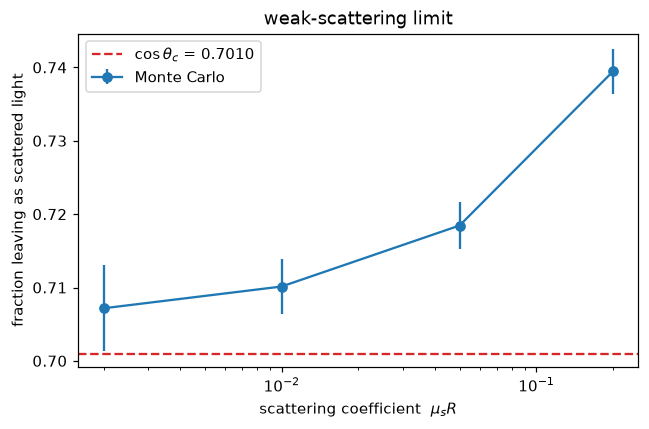

In [8]:
mu = np.array([r[0] for r in results])
fs = np.array([r[1] for r in results])
es = np.array([r[2] for r in results])

# linear extrapolation to mu_s -> 0 using the two weakest-scattering runs
slope = (fs[-2] - fs[-1]) / (mu[-2] - mu[-1])
f_extrap = fs[-1] - slope * mu[-1]
print(f"extrapolated to zero scattering: f = {f_extrap:.4f}")
print(f"analytic                       : f = {f_analytic:.4f}")

plt.figure(figsize=(6, 4))
plt.errorbar(mu, fs, yerr=es, fmt="o-", label="Monte Carlo")
plt.axhline(f_analytic, color="tab:red", ls="--",
            label=r"$\cos\theta_c$ = %.4f" % f_analytic)
plt.xscale("log")
plt.xlabel(r"scattering coefficient  $\mu_s R$")
plt.ylabel("fraction leaving as scattered light")
plt.title("weak-scattering limit")
plt.legend()
plt.tight_layout()
plt.show()

### A second, sharper Monte Carlo test

The statement "a ray is trapped for good iff $\theta>\theta_c$" is the load-bearing part of the
argument, so let us test it directly: emit photons with **no scattering at all** ($\mu_s=0$) and
simply record whether the photon escapes within, say, a thousand wall hits, together with its
initial angle to the surface normal.

In [9]:
def escapes_without_scattering(n, rng, max_hits=1000):
    """trace a photon with the impurities switched off; return (escaped?, initial angle)"""
    sin_c = 1.0 / n
    p = [0.0, 0.0, -1.0 + 1e-9]
    u = random_direction(rng)
    theta0 = math.degrees(math.acos(abs(u[2])))   # angle to the local normal at the dye

    for _ in range(max_hits):
        p = [p[i] + distance_to_surface(p, u) * u[i] for i in range(3)]
        length = math.sqrt(sum(c * c for c in p))
        normal = [c / length for c in p]
        cos_i = sum(u[i] * normal[i] for i in range(3))
        sin_i = math.sqrt(max(0.0, 1.0 - cos_i * cos_i))
        if sin_i <= sin_c:
            return True, theta0
        u = [u[i] - 2.0 * cos_i * normal[i] for i in range(3)]
        p = [c * (1.0 - 1e-12) for c in p]
    return False, theta0


rng = random.Random(7)
angles_out, angles_trapped = [], []
for _ in range(30000):
    escaped, theta0 = escapes_without_scattering(n, rng)
    (angles_out if escaped else angles_trapped).append(theta0)

trapped_fraction = len(angles_trapped) / 30000
theta_c = math.degrees(math.asin(1 / n))
print(f"trapped fraction (pure ray tracing) : {trapped_fraction:.4f}")
print(f"cos(theta_c)                        : {f_analytic:.4f}")
print(f"largest escaping initial angle      : {max(angles_out):.2f} deg")
print(f"smallest trapped initial angle      : {min(angles_trapped):.2f} deg")
print(f"critical angle                      : {theta_c:.2f} deg")

trapped fraction (pure ray tracing) : 0.7009
cos(theta_c)                        : 0.7010
largest escaping initial angle      : 45.49 deg
smallest trapped initial angle      : 45.50 deg
critical angle                      : 45.50 deg


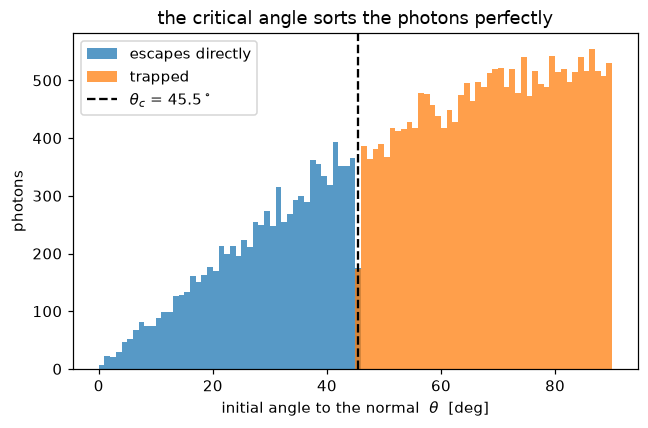

In [10]:
plt.figure(figsize=(6, 4))
bins = np.linspace(0, 90, 91)
plt.hist(angles_out, bins=bins, alpha=0.75, label="escapes directly")
plt.hist(angles_trapped, bins=bins, alpha=0.75, label="trapped")
plt.axvline(theta_c, color="k", ls="--", label=r"$\theta_c$ = %.1f$^\circ$" % theta_c)
plt.xlabel(r"initial angle to the normal  $\theta$  [deg]")
plt.ylabel("photons")
plt.title("the critical angle sorts the photons perfectly")
plt.legend()
plt.tight_layout()
plt.show()

The two histograms do not overlap by a single bin: the initial angle alone decides the fate
of a ray, exactly as the chord argument says. And the trapped fraction comes out equal to
$\cos\theta_c$ to within the Monte Carlo error.

---

## Part 4 — Sensitivity and the final number

n            = 1.402
theta_c      = 45.50 deg
direct       = 0.2990  of the emitted energy
scattered    = 0.7010  of the emitted energy

ANSWER: about 0.70  (~70 %)


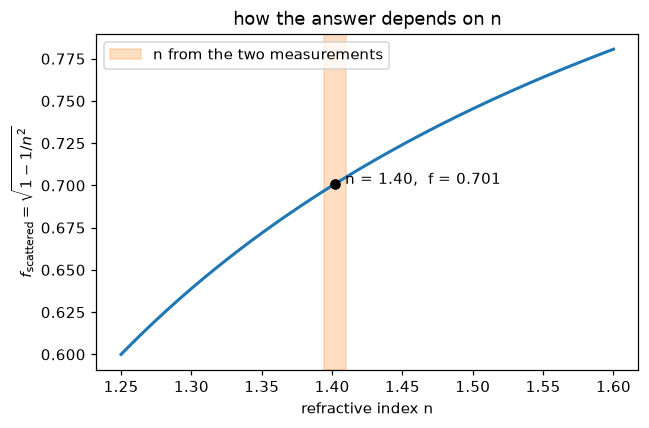

In [11]:
grid = np.linspace(1.25, 1.60, 200)

plt.figure(figsize=(6, 4))
plt.plot(grid, np.sqrt(1 - 1 / grid ** 2), lw=2)
plt.axvspan(min(n_from_halo, n_from_disc), max(n_from_halo, n_from_disc),
            color="tab:orange", alpha=0.25, label="n from the two measurements")
plt.plot([n], [f_analytic], "ko")
plt.annotate(f"  n = {n:.2f},  f = {f_analytic:.3f}", (n, f_analytic))
plt.xlabel("refractive index n")
plt.ylabel(r"$f_{\rm scattered}=\sqrt{1-1/n^2}$")
plt.title("how the answer depends on n")
plt.legend()
plt.tight_layout()
plt.show()

print(f"n            = {n:.3f}")
print(f"theta_c      = {theta_c:.2f} deg")
print(f"direct       = {1 - f_analytic:.4f}  of the emitted energy")
print(f"scattered    = {f_analytic:.4f}  of the emitted energy")
print()
print(f"ANSWER: about {f_analytic:.2f}  (~{100 * f_analytic:.0f} %)")

---

## Summary

| quantity | value |
|---|---|
| scale bar $d$ | 454 px |
| bright disc radius | $0.295\,R$ → $1-\cos\theta_c$ |
| halo radius | $1.394\,R$ → $n$ |
| refractive index | $n\approx1.40$ |
| critical angle | $\theta_c\approx45.5^\circ$ |
| escapes directly | $1-\cos\theta_c\approx0.30$ |
| **leaves as scattered light** | $\cos\theta_c\approx\mathbf{0.70}$ |

The physics in one paragraph: because the source lies *on* the sphere and reflections off a
sphere preserve the impact parameter, each ray's incidence angle is fixed for life. Rays born
inside the critical cone leave immediately; rays born outside it can never refract out, and since
nothing is absorbed, every last one of them has to come out through the weak impurity scattering.
Counting solid angle gives $\cos\theta_c$, and the figure fixes $n\approx1.40$, so
**about 70 % of the emitted energy leaves the ball as scattered light**.
